<a href="https://colab.research.google.com/github/RoshnaGeorge/ML/blob/main/Lab02_A3_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A3: IRCTC Stock Price Data Analysis

In [13]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

loading data

In [14]:
# Load the IRCTC Stock Price worksheet
stock_data = pd.read_excel(
    "Lab Session Data.xlsx",
    sheet_name="IRCTC Stock Price"
)

# Display the first five rows
print(stock_data.head())

           Date Month  Day    Price     Open     High      Low   Volume  \
0  Jun 29, 2021   Jun  Tue  2081.85  2092.00  2126.90  2065.05    1.67M   
1  Jun 28, 2021   Jun  Mon  2077.75  2084.00  2112.45  2068.40  707.73K   
2  Jun 25, 2021   Jun  Fri  2068.85  2084.35  2088.50  2053.10  475.82K   
3  Jun 24, 2021   Jun  Thu  2072.95  2098.00  2098.00  2066.00  541.51K   
4  Jun 23, 2021   Jun  Wed  2078.25  2102.00  2111.40  2072.00  809.62K   

     Chg%  
0  0.0020  
1  0.0043  
2 -0.0020  
3 -0.0026  
4 -0.0023  


In [15]:
# Display all column names
print(stock_data.columns)

Index(['Date', 'Month', 'Day', 'Price', 'Open', 'High', 'Low', 'Volume',
       'Chg%'],
      dtype='object')


calculate mean and variance

In [16]:
# Extract the Price column
price_data = stock_data['Price']

# Calculate mean using NumPy
numpy_mean = np.mean(price_data)

# Calculate variance using NumPy
numpy_variance = np.var(price_data)

# Display the results
print("Mean of Price:", numpy_mean)
print("Variance of Price:", numpy_variance)

Mean of Price: 1560.6634538152612
Variance of Price: 58496.49239931618


custom code for mean and variance

In [17]:
# Custom function to calculate mean
def calculate_mean(data):
    total = sum(data)
    return total / len(data)


# Custom function to calculate variance
def calculate_variance(data):
    mean = calculate_mean(data)
    squared_differences = [(value - mean) ** 2 for value in data]
    return sum(squared_differences) / len(data)


# Calculate mean and variance using custom functions
custom_mean = calculate_mean(price_data)
custom_variance = calculate_variance(price_data)

# Display the results
print("Custom Mean:", custom_mean)
print("NumPy Mean:", numpy_mean)

print("\nCustom Variance:", custom_variance)
print("NumPy Variance:", numpy_variance)

Custom Mean: 1560.6634538152612
NumPy Mean: 1560.6634538152612

Custom Variance: 58496.492399316136
NumPy Variance: 58496.49239931618


Comparing execution time

In [18]:
# Lists to store execution times
custom_mean_times = []
numpy_mean_times = []
custom_variance_times = []
numpy_variance_times = []

# Run each function 10 times
for i in range(10):

    # Custom Mean
    start_time = time.perf_counter()
    calculate_mean(price_data)
    end_time = time.perf_counter()
    custom_mean_times.append(end_time - start_time)

    # NumPy Mean
    start_time = time.perf_counter()
    np.mean(price_data)
    end_time = time.perf_counter()
    numpy_mean_times.append(end_time - start_time)

    # Custom Variance
    start_time = time.perf_counter()
    calculate_variance(price_data)
    end_time = time.perf_counter()
    custom_variance_times.append(end_time - start_time)

    # NumPy Variance
    start_time = time.perf_counter()
    np.var(price_data)
    end_time = time.perf_counter()
    numpy_variance_times.append(end_time - start_time)


# Calculate average execution times
avg_custom_mean_time = sum(custom_mean_times) / 10
avg_numpy_mean_time = sum(numpy_mean_times) / 10

avg_custom_variance_time = sum(custom_variance_times) / 10
avg_numpy_variance_time = sum(numpy_variance_times) / 10


# Display average execution times
print("Average Execution Time - Custom Mean:", avg_custom_mean_time)
print("Average Execution Time - NumPy Mean:", avg_numpy_mean_time)

print("\nAverage Execution Time - Custom Variance:", avg_custom_variance_time)
print("Average Execution Time - NumPy Variance:", avg_numpy_variance_time)

Average Execution Time - Custom Mean: 4.969029998846963e-05
Average Execution Time - NumPy Mean: 8.104110000886066e-05

Average Execution Time - Custom Variance: 8.850189998383939e-05
Average Execution Time - NumPy Variance: 6.893030000583167e-05


price data for all wednesdays

In [19]:
# Select Price data for Wednesdays
wednesday_prices = stock_data[stock_data['Day'] == 'Wed']['Price']

# Calculate the sample mean of Wednesday prices
wednesday_mean = np.mean(wednesday_prices)

# Population mean calculated from the complete Price data
population_mean = np.mean(price_data)

# Display the results
print("Number of Wednesday observations:", len(wednesday_prices))
print("Wednesday Sample Mean:", wednesday_mean)
print("Population Mean:", population_mean)

Number of Wednesday observations: 50
Wednesday Sample Mean: 1550.7060000000001
Population Mean: 1560.6634538152612


price data for April

In [20]:
# Select Price data for the month of April
april_prices = stock_data[stock_data['Month'] == 'Apr']['Price']

# Calculate the sample mean of April prices
april_mean = np.mean(april_prices)

# Population mean of the complete Price data
population_mean = np.mean(price_data)

# Display the results
print("Number of April observations:", len(april_prices))
print("April Sample Mean:", april_mean)
print("Population Mean:", population_mean)

Number of April observations: 19
April Sample Mean: 1698.9526315789474
Population Mean: 1560.6634538152612


probability of making a loss

In [21]:
# Identify loss observations using a lambda function
loss_values = stock_data['Chg%'].apply(lambda x: 1 if x < 0 else 0)

# Count the number of loss observations
number_of_losses = sum(loss_values)

# Find the total number of observations
total_observations = len(stock_data)

# Calculate the probability of making a loss
probability_of_loss = number_of_losses / total_observations

# Display the results
print("Number of Loss Observations:", number_of_losses)
print("Total Number of Observations:", total_observations)
print("Probability of Making a Loss:", probability_of_loss)

Number of Loss Observations: 124
Total Number of Observations: 249
Probability of Making a Loss: 0.4979919678714859


probability of making profit on wednesday

In [22]:
# Select observations that are Wednesdays and have a positive Chg%
wednesday_profit = stock_data[
    (stock_data['Day'] == 'Wed') & (stock_data['Chg%'] > 0)
]

# Count profitable Wednesday observations
number_of_wednesday_profits = len(wednesday_profit)

# Calculate probability of making a profit on Wednesday
probability_profit_wednesday = number_of_wednesday_profits / total_observations

# Display the results
print("Number of Profitable Wednesdays:", number_of_wednesday_profits)
print("Total Number of Observations:", total_observations)
print("Probability of Making a Profit on Wednesday:", probability_profit_wednesday)

Number of Profitable Wednesdays: 21
Total Number of Observations: 249
Probability of Making a Profit on Wednesday: 0.08433734939759036


conditional prob of making profit given today is wednesday

In [23]:
# Select all Wednesday observations
wednesday_data = stock_data[stock_data['Day'] == 'Wed']

# Count the total number of Wednesdays
total_wednesdays = len(wednesday_data)

# Calculate conditional probability of profit given Wednesday
conditional_probability = number_of_wednesday_profits / total_wednesdays

# Display the results
print("Number of Profitable Wednesdays:", number_of_wednesday_profits)
print("Total Number of Wednesdays:", total_wednesdays)
print("Conditional Probability of Profit Given Wednesday:", conditional_probability)

Number of Profitable Wednesdays: 21
Total Number of Wednesdays: 50
Conditional Probability of Profit Given Wednesday: 0.42


scatter plot

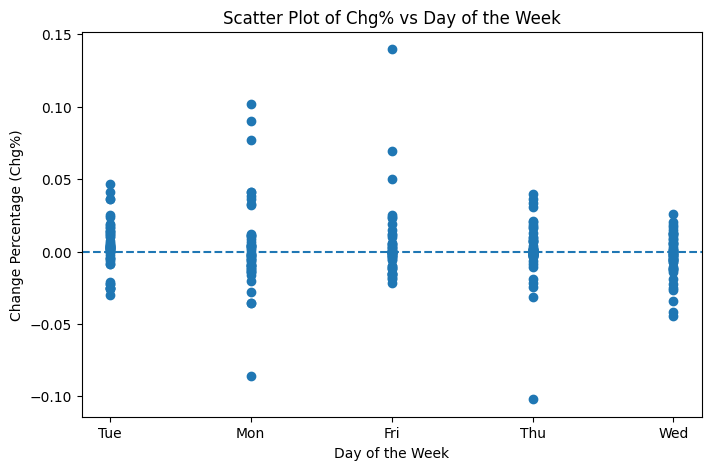

In [24]:
# Create scatter plot of Chg% against Day
plt.figure(figsize=(8, 5))

plt.scatter(stock_data['Day'], stock_data['Chg%'])

plt.xlabel("Day of the Week")
plt.ylabel("Change Percentage (Chg%)")
plt.title("Scatter Plot of Chg% vs Day of the Week")

plt.axhline(y=0, linestyle='--')

plt.show()